# Optimizers

A machine has a dial showing zero; we want it to show three. The dial is a **parameter**, its mistake score is the **loss**, and an **optimizer** chooses how to move it. We will watch small moves, add memory, then compare two-dial paths.

Run from a fresh kernel using the [README setup](README.md). Everything runs on CPU with no downloads or credentials. The [illustrated notes](08_Optimizers_Notes.ipynb) explain the same journey independently.

## Prepare the tools

PyTorch handles numbers and gradients; NumPy prepares plotting arrays; Matplotlib draws pictures. Fixed seeds and deterministic settings support reproducibility. `float64` gives extra precision for arithmetic comparisons. The version printout identifies the environment.

## Start with the problem this lesson solves

A gradient tells us a local direction, but a network still needs a rule for actually moving its parameters. The optimizer chooses that move. Too small a learning rate may make progress slow; too large a rate may overshoot and increase loss.

We isolate one parameter so the update is visible. Think of a neuron with constant input one, no bias, and prediction $w$. Its target is three. The loss is $L(w)=	frac12(w-3)^2$. The same update principles apply to the many weights of an ANN.

## Compare complete parameter updates on one tiny problem

Start at $w=0$. Prediction is zero, error is $0-3=-3$, loss is $\tfrac12(-3)^2=4.5$, and gradient is $g=w-3=-3$.

**Plain SGD:** with rate $\eta=0.1$, use $w'=w-\eta g=0-0.1(-3)=0.3$. New loss is $\tfrac12(0.3-3)^2=3.645$. At the next step the gradient is recomputed: $0.3-3=-2.7$. The next weight is $0.3-0.1(-2.7)=0.57$, with loss $\tfrac12(-2.43)^2=2.95245$. Reusing the first gradient forever would not be ordinary gradient descent.

**Why the rate matters:** from the original $w=0$, a rate of one gives $w'=3$, reaching the minimum of this particular quadratic in one step. A rate of three gives $w'=9$ and loss $\tfrac12(9-3)^2=18$, worse than $4.5$. The negative-gradient direction was correct locally; the move was too large.

**Momentum:** use buffer $m_t=0.9m_{t-1}+g_t$, start $m_0=0$, and update $w_t=w_{t-1}-0.1m_t$. First $m_1=-3$ and $w_1=0.3$. Next $g_2=-2.7$, so $m_2=0.9(-3)-2.7=-5.4$ and $w_2=0.3-0.1(-5.4)=0.84$. The buffer carries some earlier direction into the new step. This can accelerate consistent progress but can also overshoot.

**Adam's first step:** restart at zero with gradient $-3$, first-moment factor $0.9$, second-moment factor $0.999$, and zero initial records:

$$m_1=0.9(0)+0.1(-3)=-0.3,$$
$$v_1=0.999(0)+0.001(-3)^2=0.009.$$

Correct the zero-start bias: $\hat m_1=-0.3/(1-0.9)=-3$ and $\hat v_1=0.009/(1-0.999)=9$. At rate $0.1$,

$$w_1=0-0.1\frac{-3}{\sqrt9+10^{-8}}\approx0.1.$$

The new loss is approximately $\tfrac12(0.1-3)^2=4.205$. Here Adam's first move is smaller than SGD's. This single step does not rank optimizers generally: the methods manage direction and scale differently over a whole training trajectory.

## Why an ANN needs this separate step

Backpropagation computes the current gradient. SGD uses it directly; momentum keeps a direction buffer; Adam keeps direction and squared-gradient records for each parameter. These records are additional optimizer state, not additional neurons.

The learning rate still matters with Adam. Weight decay is another choice that discourages large parameter values; it is distinct from merely following the data loss. Validation performance and stable learning curves are more useful than assuming one optimizer is always best. At inference, only the learned model computation is needed; optimizer state is needed to resume the same training process.

## Connect the explanation to the code

`optimizer.zero_grad()` clears the model's accumulated gradients, not momentum or Adam's internal records. `loss.backward()` fills gradients for the current computation. `optimizer.step()` applies the selected rule and changes parameters. Constructing a fresh optimizer inside every iteration would reset its useful history. The scalar examples restart deliberately so the methods can be inspected from the same starting point.

The calculations above explain the mechanism before the full experiment. Read the following code cells in order; the printed values and assertions let you compare the implementation with its mathematical meaning.

In [1]:
import platform
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
DTYPE = torch.float64
plt.rcParams.update({"figure.dpi": 90})
print("Python:", platform.python_version(), "| PyTorch:", torch.__version__)
print("CPU | deterministic toy objectives | double precision")

Python: 3.9.6 | PyTorch: 2.2.2
CPU | deterministic toy objectives | double precision


## Move one dial once

For $L(w)=(w-3)^2/2$, the gradient at zero is minus three. A learning rate of `0.1` gives $0-0.1(-3)=0.3$.

| Code | Purpose |
| --- | --- |
| `Parameter(...)` | Mark the dial as adjustable |
| `SGD([w], lr=0.1)` | Choose the update rule and rate |
| `zero_grad(...)` | Clear old gradients |
| `backward()` | Calculate the current gradient |
| `step()` | Move the dial |

`item()` retrieves a number for printing. Assertions verify the demonstration’s arithmetic automatically.

In [2]:
def scalar_loss(w):
    return 0.5 * (w - 3.).square()

w = torch.nn.Parameter(torch.tensor(0., dtype=DTYPE))
optimizer = torch.optim.SGD([w], lr=0.1)
optimizer.zero_grad(set_to_none=True)
loss = scalar_loss(w)
loss.backward()
torch.testing.assert_close(w, torch.tensor(0., dtype=DTYPE))
torch.testing.assert_close(w.grad, torch.tensor(-3., dtype=DTYPE))
print(f"Before step: parameter={w.item():.3f}, gradient={w.grad.item():.3f}, loss={loss.item():.3f}")
optimizer.step()
torch.testing.assert_close(w, torch.tensor(0.3, dtype=DTYPE))
print(f"After step:  parameter={w.item():.3f}, loss={scalar_loss(w).item():.3f}")

Before step: parameter=0.000, gradient=-3.000, loss=4.500
After step:  parameter=0.300, loss=3.645


## Picture that first move

The curve shows loss at different dial positions. The arrow connects the starting guess to the updated guess. The number line shows the same move more simply; the star marks the goal.

`linspace` supplies evenly spaced positions and `annotate` draws an arrow. Plotting does not update the parameter again.

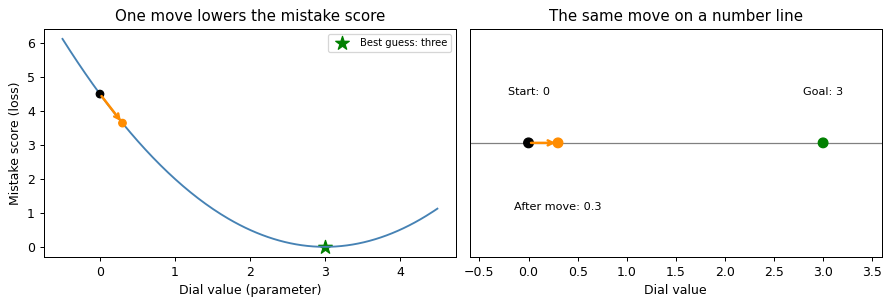

In [3]:
positions = np.linspace(-0.5, 4.5, 200)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(positions, 0.5 * (positions - 3.)**2, color="steelblue")
axes[0].scatter([0., 0.3], [4.5, 3.645], color=["black", "darkorange"], zorder=3)
axes[0].annotate("", xy=(0.3, 3.645), xytext=(0., 4.5),
                 arrowprops={"arrowstyle": "->", "color": "darkorange", "lw": 2})
axes[0].scatter([3.], [0.], marker="*", s=130, color="green", label="Best guess: three")
axes[0].set(xlabel="Dial value (parameter)", ylabel="Mistake score (loss)", title="One move lowers the mistake score")
axes[0].legend(fontsize=8)
axes[1].axhline(0., color="gray", lw=1)
axes[1].scatter([0., 0.3, 3.], [0., 0., 0.], color=["black", "darkorange", "green"], s=60, zorder=3)
axes[1].annotate("", xy=(0.3, 0.), xytext=(0., 0.),
                 arrowprops={"arrowstyle": "->", "color": "darkorange", "lw": 2})
for value, label, height in [(0., "Start: 0", 0.25), (0.3, "After move: 0.3", -0.35), (3., "Goal: 3", 0.25)]:
    axes[1].text(value, height, label, ha="center", fontsize=9)
axes[1].set(xlim=(-0.6, 3.6), ylim=(-0.6, 0.6), yticks=[], xlabel="Dial value", title="The same move on a number line")
plt.tight_layout()
plt.show()

## Change the step size

The helper repeats a fresh gradient calculation and update, saving each position for the plot. Each rate gets a new dial and optimizer.

Rate `0.1` approaches slowly, `1.5` crosses the goal while settling, and `2.1` jumps farther away. The dashed line is the goal. These boundaries belong to this particular bowl.

The verification uses the fact that distance from three is multiplied by `(1 - rate)` after each move; `np.arange` supplies the update counts.

Rate 0.1: final parameter=1.954, loss=0.547
Rate 1.5: final parameter=2.997, loss=0.000
Rate 2.1: final parameter=-4.781, loss=30.274


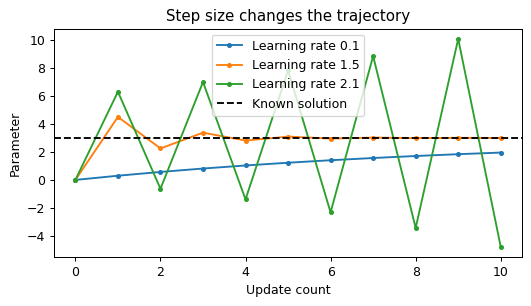

In [4]:
def scalar_trajectory(learning_rate, steps=10):
    parameter = torch.nn.Parameter(torch.tensor(0., dtype=DTYPE))
    opt = torch.optim.SGD([parameter], lr=learning_rate)
    positions = [parameter.item()]
    for _ in range(steps):
        opt.zero_grad(set_to_none=True)
        scalar_loss(parameter).backward()
        opt.step()
        positions.append(parameter.item())
    return np.array(positions)

fig, ax = plt.subplots(figsize=(6, 3.5))
for rate in [0.1, 1.5, 2.1]:
    positions = scalar_trajectory(rate)
    expected = 3. - 3. * (1. - rate) ** np.arange(len(positions))
    np.testing.assert_allclose(positions, expected, atol=1e-12)
    ax.plot(positions, marker=".", label=f"Learning rate {rate}")
    print(f"Rate {rate}: final parameter={positions[-1]:.3f}, loss={0.5 * (positions[-1]-3)**2:.3f}")
ax.axhline(3., color="black", linestyle="--", label="Known solution")
ax.set(xlabel="Update count", ylabel="Parameter", title="Step size changes the trajectory")
ax.legend()
plt.tight_layout()
plt.show()

## Add memory with momentum

Keep `0.9 × old buffer`, add the current gradient, then subtract `0.1 × buffer` from the dial. The first positions are `0.3` and `0.84`.

The optimizer is created once so its memory persists. We read `momentum_buffer` to compare it with the manual calculation. Zero dampening and disabled Nesterov select the ordinary rule explained in the notes.

In [5]:
parameter = torch.nn.Parameter(torch.tensor(0., dtype=DTYPE))
opt = torch.optim.SGD([parameter], lr=0.1, momentum=0.9, dampening=0., nesterov=False)
manual_parameter = torch.tensor(0., dtype=DTYPE)
manual_buffer = torch.tensor(0., dtype=DTYPE)
for step in range(2):
    gradient = manual_parameter - 3.
    manual_buffer = 0.9 * manual_buffer + gradient
    manual_parameter = manual_parameter - 0.1 * manual_buffer
    opt.zero_grad(set_to_none=True)
    scalar_loss(parameter).backward()
    opt.step()
    buffer = opt.state[parameter]["momentum_buffer"]
    torch.testing.assert_close(parameter, manual_parameter)
    torch.testing.assert_close(buffer, manual_buffer)
    print(f"Step {step+1}: gradient={gradient.item():.3f}, buffer={buffer.item():.3f}, parameter={parameter.item():.3f}")
torch.testing.assert_close(parameter, torch.tensor(0.84, dtype=DTYPE))

Step 1: gradient=-3.000, buffer=-3.000, parameter=0.300
Step 2: gradient=-2.700, buffer=-5.400, parameter=0.840


## Follow Adam’s records

| Value | Role |
| --- | --- |
| `m` | Average recent gradients |
| `v` | Average their squares |
| `beta1`, `beta2` | Fractions of old records retained |
| `1 - beta**step` | Correct the zero initialization |
| `epsilon` | Prevent division by zero |

Divide corrected `m` by the square root of corrected `v` plus epsilon, then multiply by the learning rate. The first move is about `+0.1`. We compare the manual records with PyTorch’s `exp_avg` and `exp_avg_sq` across two updates.

In [6]:
parameter = torch.nn.Parameter(torch.tensor(0., dtype=DTYPE))
beta1, beta2, epsilon, rate = 0.9, 0.999, 1e-8, 0.1
opt = torch.optim.Adam([parameter], lr=rate, betas=(beta1, beta2), eps=epsilon, weight_decay=0.)
manual_parameter = torch.tensor(0., dtype=DTYPE)
m = torch.tensor(0., dtype=DTYPE)
v = torch.tensor(0., dtype=DTYPE)
for step in range(1, 3):
    gradient = manual_parameter - 3.
    m = beta1 * m + (1 - beta1) * gradient
    v = beta2 * v + (1 - beta2) * gradient.square()
    corrected_m = m / (1 - beta1 ** step)
    corrected_v = v / (1 - beta2 ** step)
    manual_parameter = manual_parameter - rate * corrected_m / (corrected_v.sqrt() + epsilon)
    opt.zero_grad(set_to_none=True)
    scalar_loss(parameter).backward()
    opt.step()
    torch.testing.assert_close(parameter, manual_parameter)
    torch.testing.assert_close(opt.state[parameter]["exp_avg"], m)
    torch.testing.assert_close(opt.state[parameter]["exp_avg_sq"], v)
    print(f"Step {step}: m={m.item():.6f}, v={v.item():.6f}, "
          f"corrected m={corrected_m.item():.6f}, corrected v={corrected_v.item():.6f}, "
          f"parameter={parameter.item():.6f}")

Step 1: m=-0.300000, v=0.009000, corrected m=-3.000000, corrected v=9.000000, parameter=0.100000
Step 2: m=-0.560000, v=0.017401, corrected m=-2.947368, corrected v=8.704852, parameter=0.199897


## Move two dials through a narrow valley

The loss $a^2/2+10b^2$ is steeper in $b$; its gradient is $(a,20b)$. Each optimizer starts at `(4, 1)` with independent state and eighty updates. The printed settings illustrate behavior rather than establish a winner.

`lambda p:` creates an optimizer for parameter `p`. `detach().clone()` saves a snapshot without gradient history. `stack` joins snapshots into a table and `.numpy()` prepares it for plotting. We record the initial loss and the loss after each move.

In [7]:
def valley_loss(parameters):
    return 0.5 * parameters[0].square() + 10. * parameters[1].square()

settings = {
    "SGD, lr=0.05": lambda p: torch.optim.SGD([p], lr=0.05),
    "Momentum, lr=0.05": lambda p: torch.optim.SGD([p], lr=0.05, momentum=0.9),
    "Adam, lr=0.1": lambda p: torch.optim.Adam([p], lr=0.1),
}
trajectories = {}
for name, make_optimizer in settings.items():
    parameters = torch.nn.Parameter(torch.tensor([4., 1.], dtype=DTYPE))
    opt = make_optimizer(parameters)
    path = [parameters.detach().clone()]
    losses = [valley_loss(parameters).item()]
    for _ in range(80):
        opt.zero_grad(set_to_none=True)
        objective = valley_loss(parameters)
        objective.backward()
        opt.step()
        path.append(parameters.detach().clone())
        losses.append(valley_loss(parameters).item())
    path = torch.stack(path).numpy()
    losses = np.array(losses)
    assert np.isfinite(path).all() and np.isfinite(losses).all()
    assert losses[-1] < losses[0]
    trajectories[name] = (path, losses)
    print(f"{name:22s}: final position={np.round(path[-1], 5)}, loss={losses[-1]:.6f}")

SGD, lr=0.05          : final position=[0.06606 0.     ], loss=0.002182
Momentum, lr=0.05     : final position=[0.02939 0.00378], loss=0.000575
Adam, lr=0.1          : final position=[-0.08842  0.00539], loss=0.004200


## Read the paths beside the loss

On the left, gray contours connect equal-loss points and the star marks the minimum. `meshgrid` makes the map’s background grid. Colored paths show the parameter positions.

On the right, a logarithmic axis reveals small losses; equal vertical distances represent multiplicative changes. A tiny display floor handles exact zero, whose logarithm is not finite. Overshooting or temporarily rising loss can occur; these paths describe only the listed settings.

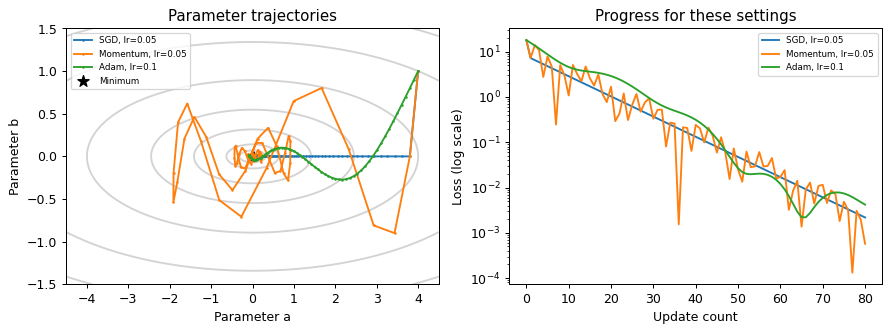

In [8]:
a_grid, b_grid = np.meshgrid(np.linspace(-4.5, 4.5, 180), np.linspace(-1.5, 1.5, 160))
surface = 0.5 * a_grid**2 + 10 * b_grid**2
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].contour(a_grid, b_grid, surface, levels=[0.05, 0.2, 1., 3., 8., 18., 30.], colors="lightgray")
for name, (path, losses) in trajectories.items():
    axes[0].plot(path[:, 0], path[:, 1], marker=".", markersize=2, label=name)
    axes[1].semilogy(np.arange(len(losses)), np.maximum(losses, np.finfo(float).tiny), label=name)
axes[0].scatter([0.], [0.], marker="*", color="black", s=90, label="Minimum")
axes[0].set(xlabel="Parameter a", ylabel="Parameter b", title="Parameter trajectories")
axes[1].set(xlabel="Update count", ylabel="Loss (log scale)", title="Progress for these settings")
axes[0].legend(fontsize=7)
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

## Isolate weight decay

AdamW shrinks separately: `2 × (1 - 0.1 × 0.1) = 1.98`. Coupled Adam adds the L2-penalty gradient, `0.1 × 2`, to its adaptive records; its first result is about `1.9`.

`zeros_like` supplies an explicit zero data-loss gradient so only decay remains. Leaving the gradient missing (`None`) can instead skip the parameter. The expected-value calculations show why identical decay settings give different results.

In [9]:
results = {}
for name, optimizer_class in [("Adam", torch.optim.Adam), ("AdamW", torch.optim.AdamW)]:
    parameter = torch.nn.Parameter(torch.tensor(2., dtype=DTYPE))
    opt = optimizer_class([parameter], lr=0.1, weight_decay=0.1,
                          betas=(0.9, 0.999), eps=1e-8)
    parameter.grad = torch.zeros_like(parameter)
    opt.step()
    results[name] = parameter.detach().clone()
    print(f"{name:5s}: parameter after decay-only step = {parameter.item():.8f}")
expected_adam = torch.tensor(2. - 0.1 * 0.2 / (0.2 + 1e-8), dtype=DTYPE)
expected_adamw = torch.tensor(2. * (1. - 0.1 * 0.1), dtype=DTYPE)
torch.testing.assert_close(results["Adam"], expected_adam)
torch.testing.assert_close(results["AdamW"], expected_adamw)

Adam : parameter after decay-only step = 1.90000000
AdamW: parameter after decay-only step = 1.98000000


## What the pictures show

SGD uses the current gradient. Momentum remembers earlier signals. Adam keeps direction and squared-size records. AdamW separates shrinkage from those records.

Their paths depend on the objective and settings. These worked calculations explain parameter movement; they do not establish predictive performance on real data.

In [ ]:
import numpy as np
from torch import nn
x_opt = torch.tensor([1., 2., 3., 4.]); y_opt = 2 * x_opt
w = torch.tensor(0., requires_grad=True)
per_example = (w.detach() * x_opt - y_opt) * x_opt
full, = torch.autograd.grad(.5 * (w * x_opt - y_opt).square().mean(), w)
torch.testing.assert_close(full, per_example.mean())
print('per-example gradients:', per_example.tolist(), '| full mean:', full.item())

optimizers = {'Nesterov': lambda p: torch.optim.SGD([p], lr=.1, momentum=.9, nesterov=True),
              'AdaGrad': lambda p: torch.optim.Adagrad([p], lr=.1),
              'RMSProp': lambda p: torch.optim.RMSprop([p], lr=.1, alpha=.9),
              'Nadam': lambda p: torch.optim.NAdam([p], lr=.1)}
fig, ax = plt.subplots(figsize=(7, 3.5))
for name, make in optimizers.items():
    dial = nn.Parameter(torch.tensor(0.)); opt = make(dial); path = [dial.item()]
    for _ in range(20):
        opt.zero_grad(set_to_none=True); (.5 * (dial - 3).square()).backward(); opt.step(); path.append(dial.item())
    ax.plot(path, label=name)
ax.axhline(3, color='gray', linestyle='--'); ax.legend(); ax.set(xlabel='update', ylabel='value'); plt.tight_layout(); plt.show()
steps = np.arange(13); step = .1 * .5 ** (steps // 3); exponential = .1 * .8 ** steps; cosine = .001 + .5 * (.1 - .001) * (1 + np.cos(np.pi * steps / 12))
assert np.isclose(step[2], .1) and np.isclose(step[3], .05) and np.isclose(cosine[-1], .001)
print('step:', step[:5].tolist(), '| exponential final:', exponential[-1], '| cosine final:', cosine[-1])